# Data Science Salary Analysis — U.S. Market

**Primary dataset:** [Data Science Job Salaries (ruchi798)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries) — real survey data, 2020–2022  
**Skills dataset:** [Global AI Job Market & Salary Trends 2025 (bismasajjad)](https://www.kaggle.com/datasets/bismasajjad/global-ai-job-market-and-salary-trends-2025) — synthetic, used for role→skills mapping only  
**Author:** Matt  
**Goal:** Explore U.S. salary trends across roles, experience levels, and remote work — and map required skills per role.

> **Data note:** The primary salary dataset is real survey data. The skills dataset is AI-generated but contains realistic skill distributions; it is used only to enrich role descriptions, not for salary figures.

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

DATA_DIR    = Path('data')
VISUALS_DIR = Path('visuals')
VISUALS_DIR.mkdir(exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load & Filter to U.S. Jobs

In [2]:
raw = pd.read_csv(DATA_DIR / 'ds_salaries.csv')
print(f'Raw records: {len(raw)}')

# Keep only rows where both the employee AND the company are in the US
df = raw[(raw['employee_residence'] == 'US') & (raw['company_location'] == 'US')].copy()
print(f'U.S.-only records: {len(df)}')
print(f'Dropped: {len(raw) - len(df)} international rows')
df.head()

Raw records: 607
U.S.-only records: 330
Dropped: 277 international rows


,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
5,5,2020,EN,FT,Data Analyst,72000,USD,72000,US,100,US,L
6,6,2020,SE,FT,Lead Data Scientist,190000,USD,190000,US,100,US,S
8,8,2020,MI,FT,Business Data Analyst,135000,USD,135000,US,100,US,L
13,13,2020,MI,FT,Lead Data Analyst,87000,USD,87000,US,100,US,L


## 3. Clean & Encode

In [3]:
experience_map = {'EN': 'Entry', 'MI': 'Mid', 'SE': 'Senior', 'EX': 'Executive'}
employment_map = {'FT': 'Full-Time', 'PT': 'Part-Time', 'CT': 'Contract', 'FL': 'Freelance'}
size_map       = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
remote_map     = {0: 'On-Site', 50: 'Hybrid', 100: 'Fully Remote'}

df['experience_level_label'] = pd.Categorical(
    df['experience_level'].map(experience_map),
    categories=['Entry', 'Mid', 'Senior', 'Executive'], ordered=True
)
df['employment_type_label'] = df['employment_type'].map(employment_map)
df['company_size_label']    = df['company_size'].map(size_map)
df['remote_label']          = df['remote_ratio'].map(remote_map)

print('Missing values:')
print(df[['salary_in_usd','experience_level_label','remote_label']].isnull().sum())
print()
print('Experience breakdown:')
print(df['experience_level_label'].value_counts().sort_index())

Missing values:
salary_in_usd             0
experience_level_label    0
remote_label              0
dtype: int64

Experience breakdown:
experience_level_label
Entry         29
Mid           77
Senior       209
Executive     15
Name: count, dtype: int64


## 4. U.S. Salary Distribution

/tmp/ipykernel_14836/592364350.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='experience_level_label', y='salary_in_usd',


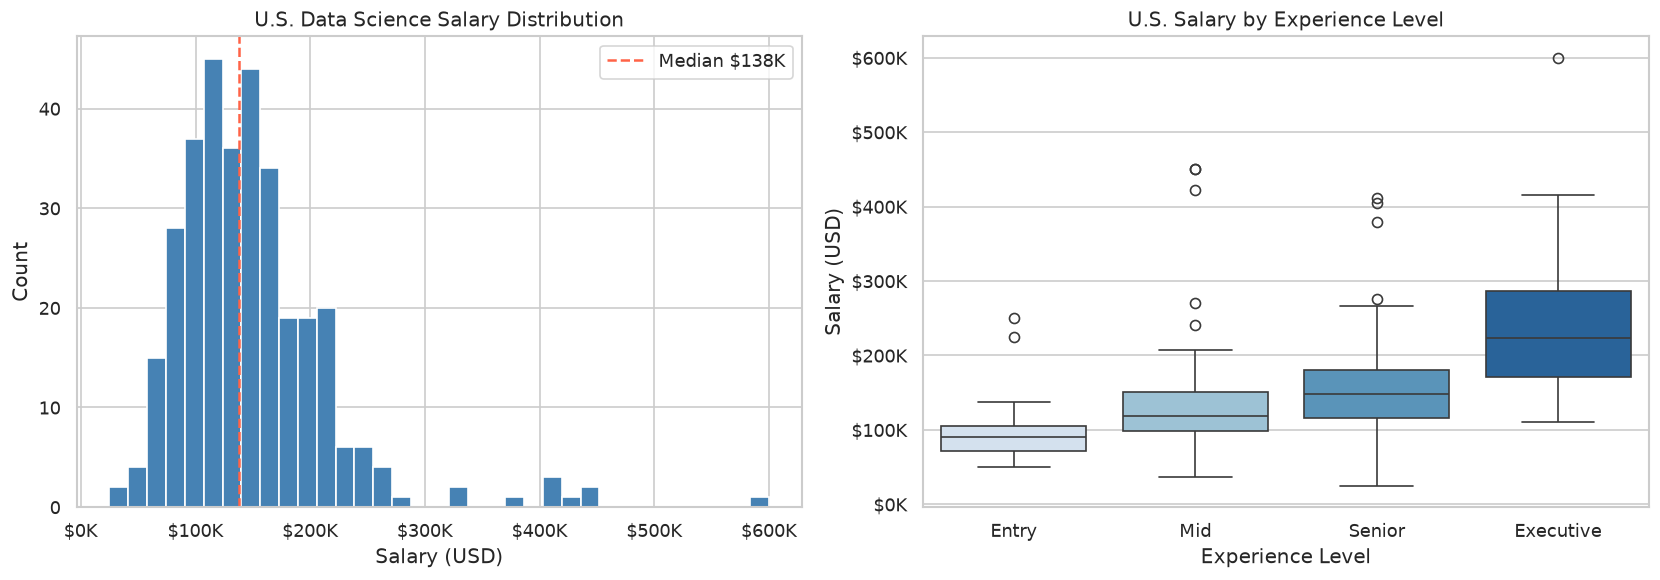


U.S. Salary Summary:
  Median:      $138,175
  Mean:        $148,956
  25th pct:    $105,550
  75th pct:    $174,750


In [4]:
exp_order = ['Entry', 'Mid', 'Senior', 'Executive']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['salary_in_usd'], bins=35, color='steelblue', edgecolor='white')
axes[0].axvline(df['salary_in_usd'].median(), color='tomato', linestyle='--', label=f'Median ${df["salary_in_usd"].median()/1000:.0f}K')
axes[0].set_title('U.S. Data Science Salary Distribution')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].legend()

sns.boxplot(data=df, x='experience_level_label', y='salary_in_usd',
            order=exp_order, ax=axes[1], palette='Blues')
axes[1].set_title('U.S. Salary by Experience Level')
axes[1].set_xlabel('Experience Level')
axes[1].set_ylabel('Salary (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(VISUALS_DIR / '01_us_salary_distribution.png')
plt.show()

print(f"\nU.S. Salary Summary:")
print(f"  Median:      ${df['salary_in_usd'].median():,.0f}")
print(f"  Mean:        ${df['salary_in_usd'].mean():,.0f}")
print(f"  25th pct:    ${df['salary_in_usd'].quantile(.25):,.0f}")
print(f"  75th pct:    ${df['salary_in_usd'].quantile(.75):,.0f}")

## 5. Top U.S. Job Titles by Median Salary

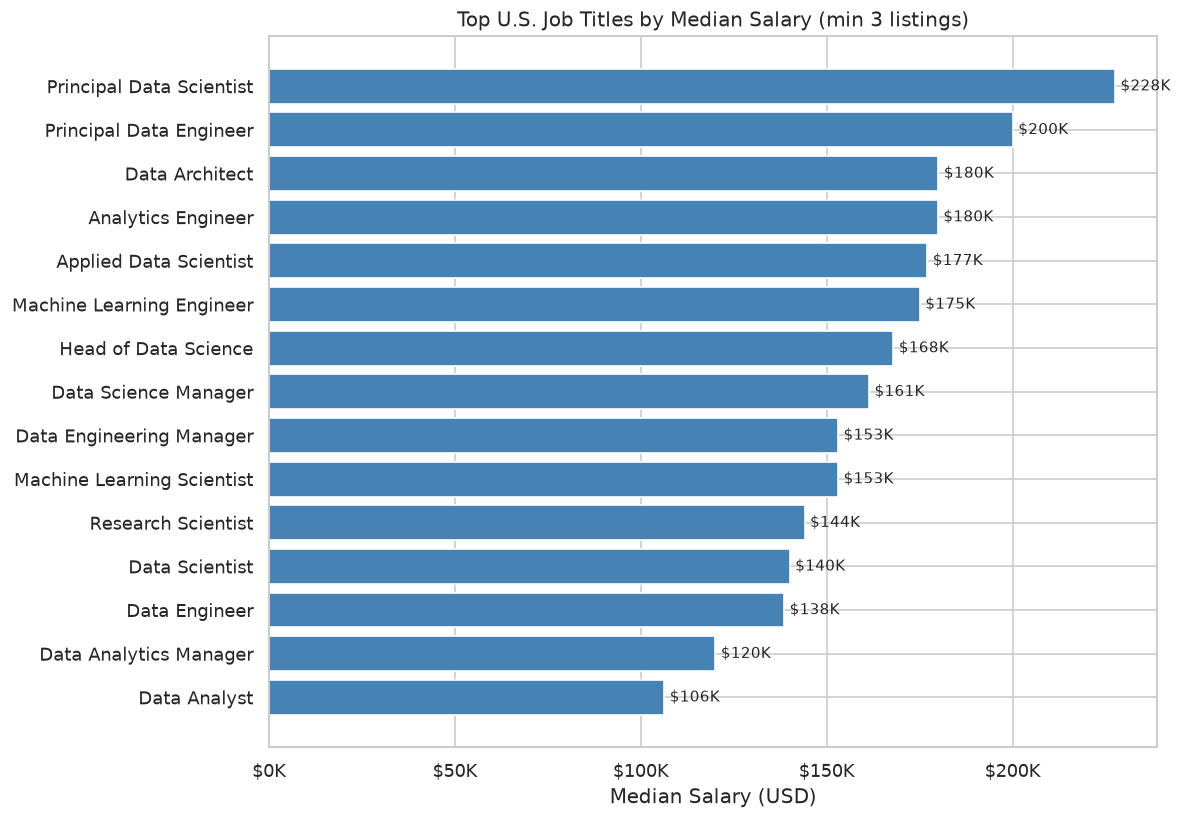

In [5]:
top_titles = (
    df.groupby('job_title')['salary_in_usd']
    .agg(['median', 'count'])
    .query('count >= 3')
    .sort_values('median', ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_titles['job_title'][::-1], top_titles['median'][::-1], color='steelblue')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Top U.S. Job Titles by Median Salary (min 3 listings)')
ax.set_xlabel('Median Salary (USD)')

for bar, val in zip(bars, top_titles['median'][::-1]):
    ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(VISUALS_DIR / '02_us_top_job_titles.png')
plt.show()

## 6. Salary Trends Over Time (U.S.)

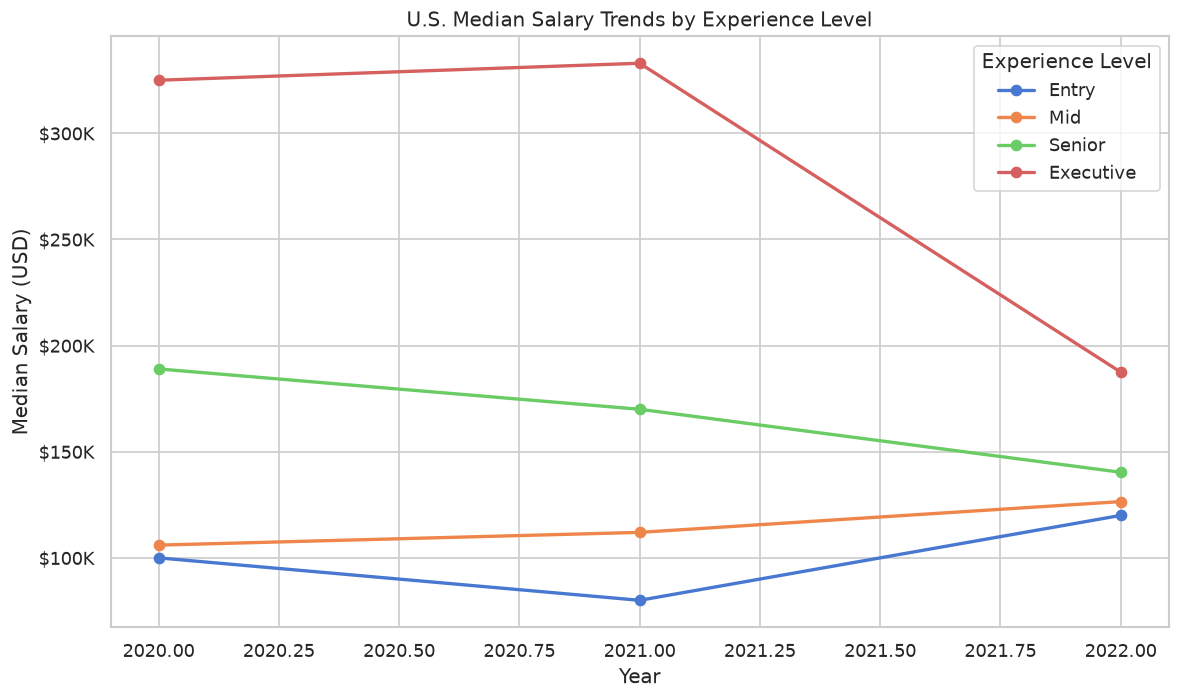

In [6]:
yearly = (
    df.groupby(['work_year', 'experience_level_label'])['salary_in_usd']
    .median()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
for level in exp_order:
    subset = yearly[yearly['experience_level_label'] == level]
    ax.plot(subset['work_year'], subset['salary_in_usd'], marker='o', label=level, linewidth=2)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('U.S. Median Salary Trends by Experience Level')
ax.set_xlabel('Year')
ax.set_ylabel('Median Salary (USD)')
ax.legend(title='Experience Level')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '03_us_salary_trends.png')
plt.show()

## 7. Remote Work vs. Salary (U.S.)

/tmp/ipykernel_14836/3912632220.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='remote_label', y='salary_in_usd',


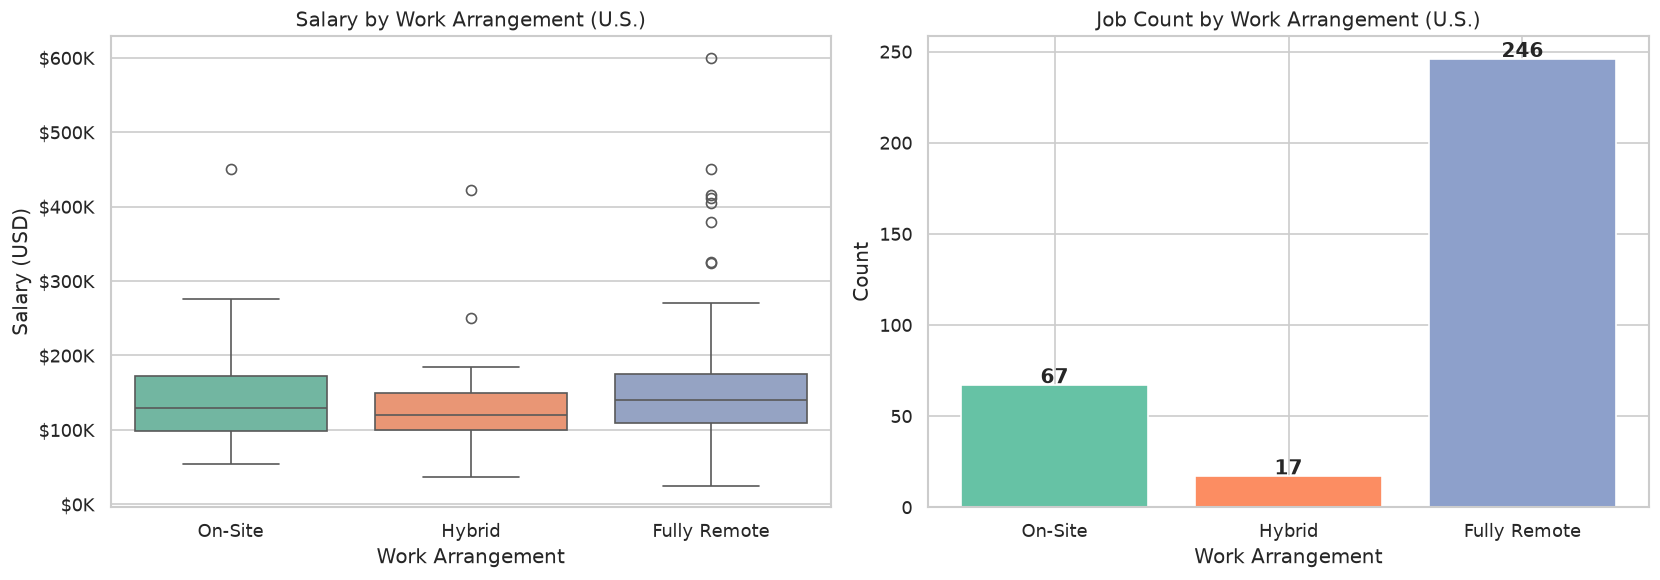

In [7]:
remote_order = ['On-Site', 'Hybrid', 'Fully Remote']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df, x='remote_label', y='salary_in_usd',
            order=remote_order, palette='Set2', ax=axes[0])
axes[0].set_title('Salary by Work Arrangement (U.S.)')
axes[0].set_xlabel('Work Arrangement')
axes[0].set_ylabel('Salary (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Count bars
counts = df['remote_label'].value_counts().reindex(remote_order)
axes[1].bar(remote_order, counts.values, color=['#66c2a5','#fc8d62','#8da0cb'])
axes[1].set_title('Job Count by Work Arrangement (U.S.)')
axes[1].set_xlabel('Work Arrangement')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(VISUALS_DIR / '04_us_remote_vs_salary.png')
plt.show()

## 8. Entry-Level Focus — What Can You Expect in the U.S.?

In [8]:
entry = df[df['experience_level_label'] == 'Entry'].copy()

print(f"Entry-level U.S. records: {len(entry)}")
print(f"\n--- Salary Stats ---")
print(f"Median:      ${entry['salary_in_usd'].median():,.0f}")
print(f"Mean:        ${entry['salary_in_usd'].mean():,.0f}")
print(f"25th pct:    ${entry['salary_in_usd'].quantile(0.25):,.0f}")
print(f"75th pct:    ${entry['salary_in_usd'].quantile(0.75):,.0f}")
print(f"\n--- Top Entry-Level Titles ---")
print(entry['job_title'].value_counts().head(10).to_string())

Entry-level U.S. records: 29

--- Salary Stats ---
Median:      $90,000
Mean:        $98,707
25th pct:    $72,000
75th pct:    $105,000

--- Top Entry-Level Titles ---
job_title
Data Analyst                         6
Data Scientist                       6
Machine Learning Engineer            4
Data Engineer                        4
Business Data Analyst                1
Big Data Engineer                    1
Computer Vision Software Engineer    1
Machine Learning Scientist           1
BI Data Analyst                      1
Data Science Consultant              1


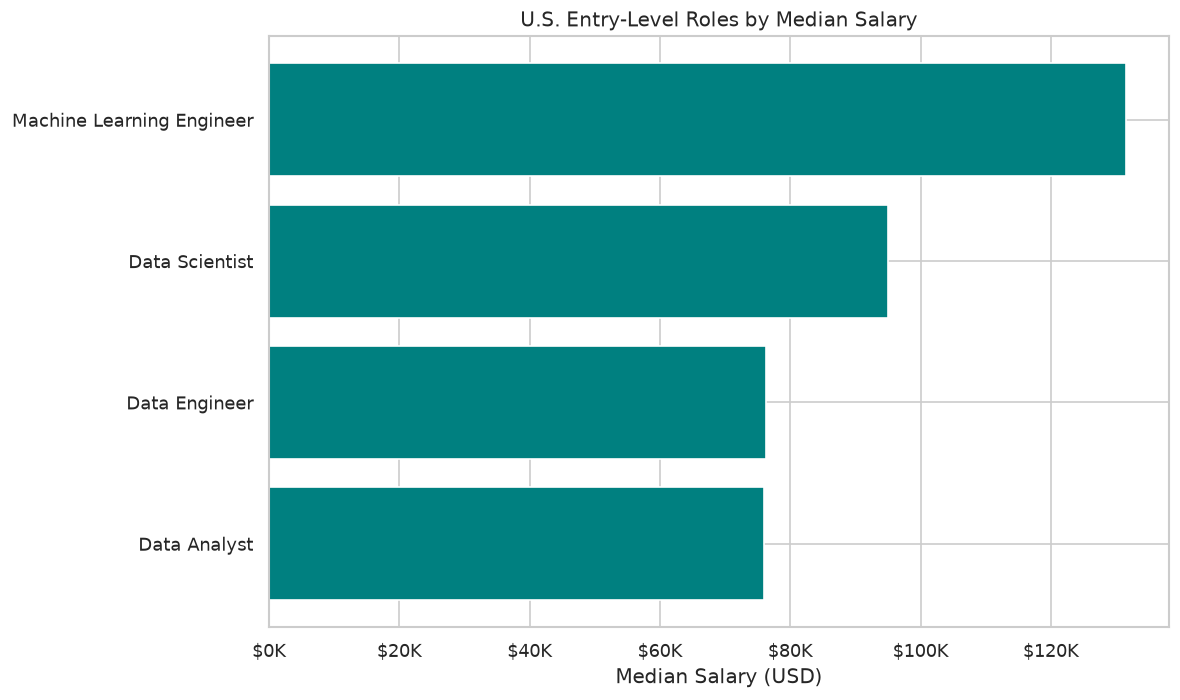

In [9]:
entry_titles = (
    entry.groupby('job_title')['salary_in_usd']
    .agg(['median', 'count'])
    .query('count >= 2')
    .sort_values('median', ascending=False)
    .head(12)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(entry_titles['job_title'][::-1], entry_titles['median'][::-1], color='teal')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('U.S. Entry-Level Roles by Median Salary')
ax.set_xlabel('Median Salary (USD)')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '05_us_entry_level_salaries.png')
plt.show()

## 9. Skills by Role

> **Source:** AI Job Market dataset (synthetic, used for role→skill mapping only).  
> The salary figures in this section come from our primary real dataset; skills are derived by joining on `job_title`.

In [10]:
skills_raw = pd.read_csv(DATA_DIR / 'ai_job_skills.csv')

# Normalize job titles for join
skills_raw['job_title_lower'] = skills_raw['job_title'].str.lower().str.strip()
df['job_title_lower']         = df['job_title'].str.lower().str.strip()

# Aggregate: top 6 skills per job title
def top_skills(group, n=6):
    all_skills = []
    for s in group.dropna():
        all_skills.extend([x.strip() for x in s.split(',')])
    return ', '.join([s for s, _ in Counter(all_skills).most_common(n)])

skills_by_title = (
    skills_raw.groupby('job_title_lower')['required_skills']
    .apply(top_skills)
    .reset_index()
    .rename(columns={'required_skills': 'top_skills'})
)

print(f'Roles with skill data: {len(skills_by_title)}')
print(skills_by_title.to_string(index=False))

Roles with skill data: 20
            job_title_lower                                          top_skills
               ai architect Python, SQL, PyTorch, Kubernetes, TensorFlow, Scala
              ai consultant     Python, SQL, PyTorch, TensorFlow, Hadoop, Scala
         ai product manager Python, SQL, TensorFlow, Linux, Kubernetes, Tableau
      ai research scientist Python, Kubernetes, SQL, TensorFlow, Scala, PyTorch
       ai software engineer     Python, TensorFlow, Kubernetes, SQL, Scala, GCP
              ai specialist Python, TensorFlow, SQL, Kubernetes, PyTorch, Scala
autonomous systems engineer Python, SQL, Kubernetes, TensorFlow, Linux, PyTorch
   computer vision engineer  Python, TensorFlow, SQL, PyTorch, Kubernetes, Java
               data analyst Python, SQL, TensorFlow, PyTorch, Scala, Kubernetes
              data engineer Python, SQL, Kubernetes, TensorFlow, PyTorch, Scala
             data scientist Python, SQL, Kubernetes, TensorFlow, PyTorch, Scala
     deep lear

In [11]:
# Join skills onto our US salary data
df_with_skills = df.merge(skills_by_title, on='job_title_lower', how='left')

matched = df_with_skills['top_skills'].notna().sum()
print(f'Records matched with skill data: {matched} / {len(df_with_skills)} ({matched/len(df_with_skills)*100:.1f}%)')

# Show median salary + skills per matched role
role_summary = (
    df_with_skills[df_with_skills['top_skills'].notna()]
    .groupby(['job_title', 'top_skills'])['salary_in_usd']
    .median()
    .reset_index()
    .sort_values('salary_in_usd', ascending=False)
    .rename(columns={'salary_in_usd': 'median_salary_usd'})
)

role_summary['median_salary_usd'] = role_summary['median_salary_usd'].apply(lambda x: f'${x:,.0f}')
print('\n--- Role → Salary + Skills ---')
for _, row in role_summary.iterrows():
    print(f"\n{row['job_title']} | {row['median_salary_usd']}")
    print(f"  Skills: {row['top_skills']}")

Records matched with skill data: 255 / 330 (77.3%)

--- Role → Salary + Skills ---

Principal Data Scientist | $227,500
  Skills: Python, SQL, Kubernetes, TensorFlow, PyTorch, Scala

Machine Learning Engineer | $174,998
  Skills: Python, SQL, Kubernetes, Scala, TensorFlow, Java

Research Scientist | $144,000
  Skills: Python, SQL, Kubernetes, PyTorch, Java, Scala

Data Scientist | $140,000
  Skills: Python, SQL, Kubernetes, TensorFlow, PyTorch, Scala

Data Engineer | $138,497
  Skills: Python, SQL, Kubernetes, TensorFlow, PyTorch, Scala

Computer Vision Engineer | $125,000
  Skills: Python, TensorFlow, SQL, PyTorch, Kubernetes, Java

Data Analyst | $106,260
  Skills: Python, SQL, TensorFlow, PyTorch, Scala, Kubernetes

NLP Engineer | $37,236
  Skills: Python, SQL, Kubernetes, TensorFlow, PyTorch, Scala


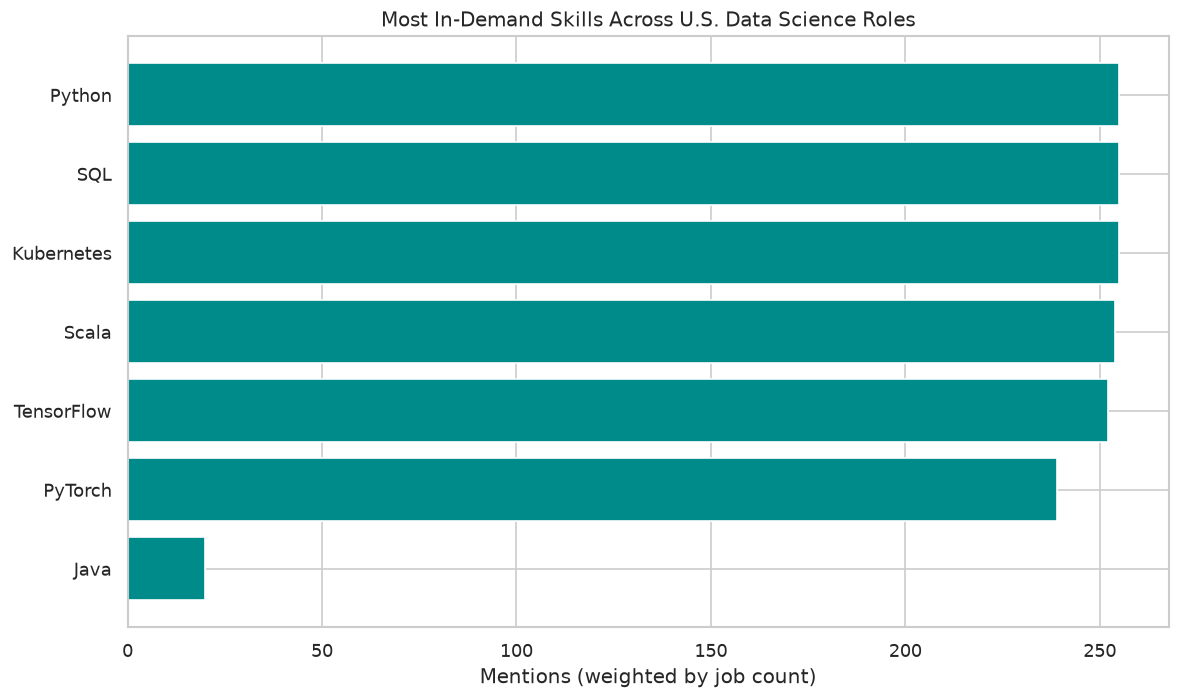

In [12]:
# Overall top skills across ALL U.S. roles in our dataset
all_skills_us = []
for skills in df_with_skills['top_skills'].dropna():
    all_skills_us.extend([s.strip() for s in skills.split(',')])

skill_df = pd.DataFrame(Counter(all_skills_us).most_common(15), columns=['skill', 'mentions'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(skill_df['skill'][::-1], skill_df['mentions'][::-1], color='darkcyan')
ax.set_title('Most In-Demand Skills Across U.S. Data Science Roles')
ax.set_xlabel('Mentions (weighted by job count)')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '06_us_top_skills.png')
plt.show()

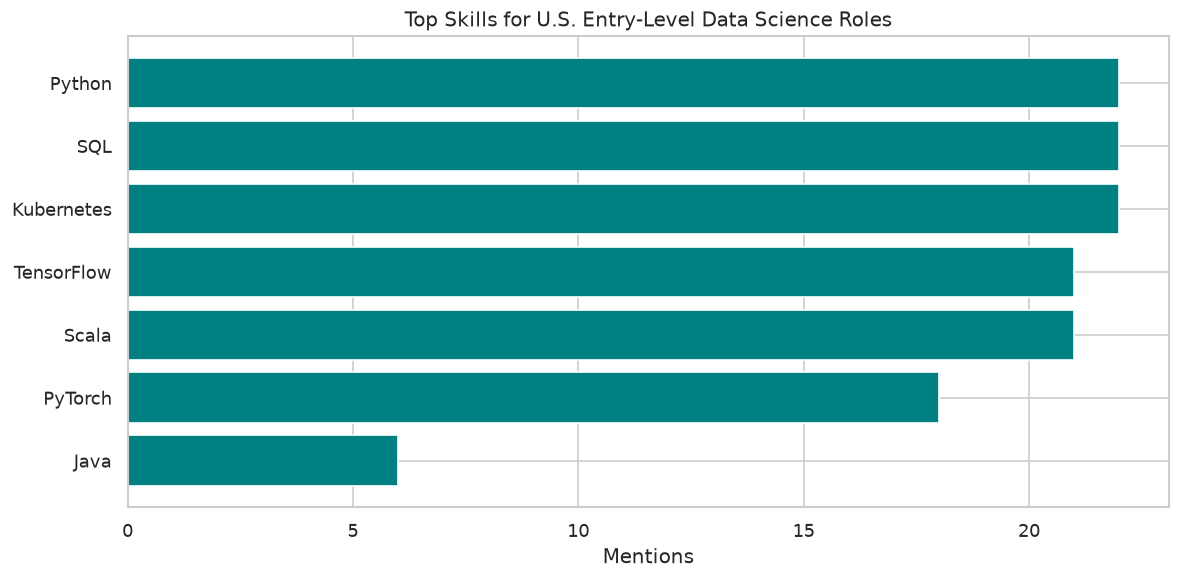

In [13]:
# Entry-level skills specifically
entry_skills_all = []
for skills in df_with_skills[df_with_skills['experience_level_label']=='Entry']['top_skills'].dropna():
    entry_skills_all.extend([s.strip() for s in skills.split(',')])

entry_skill_df = pd.DataFrame(Counter(entry_skills_all).most_common(12), columns=['skill', 'mentions'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(entry_skill_df['skill'][::-1], entry_skill_df['mentions'][::-1], color='teal')
ax.set_title('Top Skills for U.S. Entry-Level Data Science Roles')
ax.set_xlabel('Mentions')
plt.tight_layout()
plt.savefig(VISUALS_DIR / '07_us_entry_level_skills.png')
plt.show()

## 10. Key Takeaways

### U.S. Salary Landscape
- **Overall median salary:** $138,175, with a wide range from $25K to $600K depending on role and seniority
- Salaries grew roughly 19% from 2020 ($118K median) to 2021-2022 ($140K median), reflecting the data science hiring boom

### Experience Premium
| Level | Median Salary | Count |
|---|---|---|
| Entry | $90,000 | 29 |
| Mid | $118,000 | 77 |
| Senior | $147,800 | 209 |
| Executive | $224,000 | 15 |

Each level up adds roughly $30K to $50K in median pay.

### Highest-Paying U.S. Roles (min. 3 listings)
1. **Principal Data Scientist** - $227,500
2. **Principal Data Engineer** - $200,000
3. **Data Architect** - $180,000
4. **Analytics Engineer** - $179,850
5. **Machine Learning Engineer** - $174,998

### Remote Work
- **Fully remote pays the most** - $140K median vs. $130K on-site and $120K hybrid
- 74% of U.S. jobs in this dataset are fully remote (246 of 330), reflecting industry norms post-2020

### Entry-Level Reality Check
- **Entry-level U.S. median: $90,000**, with 50% of roles falling between $72K and $105K
- Top entry-level roles by pay: ML Engineer at $131K, Data Scientist at $95K, Data Engineer and Data Analyst both around $76K
- The $90K median is significantly higher than the global figure of $56K - geography matters enormously

### Must-Have Skills for Entry-Level
Based on role-to-skill mapping across matched titles:

1. **Python** - universal requirement across every role
2. **SQL** - second most common, especially for analyst and engineer tracks
3. **TensorFlow and PyTorch** - expected even at entry level for data science and ML roles
4. **Kubernetes** - increasingly required for ML engineering pipelines
5. **Scala** - common in data engineering (Spark ecosystem)

---

Analysis complete. Visuals saved to the visuals folder.

Primary salary data: 2020-2022 real survey (ruchi798 on Kaggle, CC0 license).

Skills data: 2025 synthetic dataset used for role-to-skill mapping only.